In [1]:
import os, sys, subprocess, warnings

warnings.filterwarnings("ignore")

SEED = 34
os.environ["PYTHONHASHSEED"] = str(SEED)

# Stability fix:
# The prior TensorFlow "fallback" forced pure-Python protobuf (and version=2), which in this
# environment causes the exact AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'.
# We keep protobuf env clean and import TF normally.
os.environ.pop("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", None)
os.environ.pop("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION", None)

print("Startup OK. Protobuf env override disabled; importing TensorFlow normally.")



Startup OK. Protobuf env override disabled; importing TensorFlow normally.


In [2]:
import random, gc, math, json
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

import tensorflow as tf
import tensorflow.keras.layers as L

from sklearn.model_selection import train_test_split, KFold

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)



2026-01-21 02:46:40.677174: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768963600.689907      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768963600.693951      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-21 02:46:40.709235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0


In [3]:
train = pd.read_json("/kaggle/input/stanford-covid-vaccine/train.json", lines=True)
test = pd.read_json("/kaggle/input/stanford-covid-vaccine/test.json", lines=True)
sample_sub = pd.read_csv("/kaggle/input/stanford-covid-vaccine/sample_submission.csv")

print(train.shape, test.shape, sample_sub.shape)
print("Test seq_length unique:", sorted(test["seq_length"].unique().tolist()))
print("Test seq_scored unique:", sorted(test["seq_scored"].unique().tolist()))



(2160, 19) (240, 7) (25680, 6)
Test seq_length unique: [107]
Test seq_scored unique: [68]


In [4]:
target_cols = ["reactivity", "deg_Mg_pH10", "deg_pH10", "deg_Mg_50C", "deg_50C"]



In [5]:
token2int = {x: i for i, x in enumerate("().ACGUBEHIMSX")}




In [6]:
def preprocess_inputs(
    df, cols=("sequence", "structure", "predicted_loop_type"), seq_len=107
):
    if df is None or len(df) == 0:
        return np.zeros((0, seq_len, len(cols)), dtype=np.int32)

    unk = token2int.get("X", 0)

    arr = np.zeros((len(df), seq_len, len(cols)), dtype=np.int32)
    for j, c in enumerate(cols):
        for i, s in enumerate(df[c].values):
            toks = [token2int.get(ch, unk) for ch in s]
            Ls = min(len(toks), seq_len)
            arr[i, :Ls, j] = toks[:Ls]
    return arr




In [7]:
train_f = train[(train.SN_filter == 1)].copy()

train_inputs = preprocess_inputs(train_f, seq_len=107)
train_labels = np.array(
    train_f[target_cols].values.tolist(), dtype=np.float32
).transpose((0, 2, 1))

print("Filtered train size:", train_f.shape)
print("train_inputs:", train_inputs.shape, train_inputs.dtype)
print("train_labels:", train_labels.shape, train_labels.dtype)




Filtered train size: (1349, 19)
train_inputs: (1349, 107, 3) int32
train_labels: (1349, 68, 5) float32


In [8]:
def gru_layer(hidden_dim, dropout):
    return tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            hidden_dim,
            dropout=dropout,
            return_sequences=True,
            kernel_initializer="orthogonal",
        )
    )


def lstm_layer(hidden_dim, dropout):
    return tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            hidden_dim,
            dropout=dropout,
            return_sequences=True,
            kernel_initializer="orthogonal",
        )
    )


def scored_mse(y_true, y_pred):
    yt = tf.gather(y_true, [0, 1, 3], axis=-1)
    yp = tf.gather(y_pred, [0, 1, 3], axis=-1)
    return tf.reduce_mean(tf.square(yt - yp))


def build_model(
    gru=False, seq_len=107, pred_len=68, dropout=0.2, embed_dim=75, hidden_dim=128
):
    inputs = tf.keras.layers.Input(shape=(seq_len, 3), dtype=tf.int32)

    embed = tf.keras.layers.Embedding(input_dim=len(token2int), output_dim=embed_dim)(
        inputs
    )
    reshaped = tf.keras.layers.Reshape((seq_len, 3 * embed_dim))(embed)

    reshaped = tf.keras.layers.SpatialDropout1D(0.2)(reshaped)

    if gru:
        hidden = gru_layer(hidden_dim, dropout)(reshaped)
        hidden = gru_layer(hidden_dim, dropout)(hidden)
        hidden = gru_layer(hidden_dim, dropout)(hidden)
    else:
        hidden = lstm_layer(hidden_dim, dropout)(reshaped)
        hidden = lstm_layer(hidden_dim, dropout)(hidden)
        hidden = lstm_layer(hidden_dim, dropout)(hidden)

    truncated = hidden[:, :pred_len]
    out = tf.keras.layers.Dense(5, activation="linear")(truncated)

    model = tf.keras.Model(inputs=inputs, outputs=out)
    adam = tf.optimizers.Adam()
    model.compile(optimizer=adam, loss=scored_mse)
    return model




In [9]:
train_inputs, val_inputs, train_labels, val_labels = train_test_split(
    train_inputs, train_labels, test_size=0.1, random_state=SEED
)
print(
    "Split shapes:",
    train_inputs.shape,
    val_inputs.shape,
    train_labels.shape,
    val_labels.shape,
)



Split shapes: (1214, 107, 3) (135, 107, 3) (1214, 68, 5) (135, 68, 5)


In [10]:
gpus = tf.config.list_physical_devices("GPU")
if len(gpus) > 0:
    print("Training on GPU")
else:
    print("Training on CPU")



Training on GPU


In [11]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau()



In [12]:
gru = build_model(gru=True)
sv_gru = tf.keras.callbacks.ModelCheckpoint(
    "model_gru.weights.h5",
    save_weights_only=True,
    save_best_only=True,
    monitor="val_loss",
    mode="min",
)

history_gru = gru.fit(
    train_inputs,
    train_labels,
    validation_data=(val_inputs, val_labels),
    batch_size=32,
    epochs=60,
    callbacks=[lr_callback, sv_gru],
    verbose=2,
)

print(
    f"Min training loss={min(history_gru.history['loss'])}, min validation loss={min(history_gru.history['val_loss'])}"
)



2026-01-21 02:46:47.570858: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768963607.571816      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6


Epoch 1/60


I0000 00:00:1768963611.715903      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


38/38 - 5s - 141ms/step - loss: 0.2009 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 2/60
38/38 - 1s - 26ms/step - loss: 0.1525 - val_loss: 0.1415 - learning_rate: 0.0010
Epoch 3/60
38/38 - 1s - 26ms/step - loss: 0.1335 - val_loss: 0.1258 - learning_rate: 0.0010
Epoch 4/60
38/38 - 1s - 26ms/step - loss: 0.1208 - val_loss: 0.1156 - learning_rate: 0.0010
Epoch 5/60
38/38 - 1s - 26ms/step - loss: 0.1134 - val_loss: 0.1067 - learning_rate: 0.0010
Epoch 6/60
38/38 - 1s - 25ms/step - loss: 0.1088 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 7/60
38/38 - 1s - 26ms/step - loss: 0.1032 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 8/60
38/38 - 1s - 26ms/step - loss: 0.0971 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 9/60
38/38 - 1s - 26ms/step - loss: 0.0922 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 10/60
38/38 - 1s - 26ms/step - loss: 0.0888 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 11/60
38/38 - 1s - 26ms/step - loss: 0.0844 - val_loss: 0.0815 - learning_rate: 0.0

In [13]:
lstm = build_model(gru=False)
sv_lstm = tf.keras.callbacks.ModelCheckpoint(
    "model_lstm.weights.h5",
    save_weights_only=True,
    save_best_only=True,
    monitor="val_loss",
    mode="min",
)

history_lstm = lstm.fit(
    train_inputs,
    train_labels,
    validation_data=(val_inputs, val_labels),
    batch_size=32,
    epochs=65,
    callbacks=[lr_callback, sv_lstm],
    verbose=2,
)

print(
    f"Min training loss={min(history_lstm.history['loss'])}, min validation loss={min(history_lstm.history['val_loss'])}"
)



Epoch 1/65
38/38 - 5s - 119ms/step - loss: 0.2214 - val_loss: 0.1736 - learning_rate: 0.0010
Epoch 2/65
38/38 - 1s - 25ms/step - loss: 0.1601 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 3/65
38/38 - 1s - 26ms/step - loss: 0.1463 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 4/65
38/38 - 1s - 27ms/step - loss: 0.1331 - val_loss: 0.1200 - learning_rate: 0.0010
Epoch 5/65
38/38 - 1s - 24ms/step - loss: 0.1187 - val_loss: 0.1135 - learning_rate: 0.0010
Epoch 6/65
38/38 - 1s - 26ms/step - loss: 0.1110 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 7/65
38/38 - 1s - 25ms/step - loss: 0.1052 - val_loss: 0.1017 - learning_rate: 0.0010
Epoch 8/65
38/38 - 1s - 25ms/step - loss: 0.1005 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 9/65
38/38 - 1s - 23ms/step - loss: 0.0964 - val_loss: 0.0921 - learning_rate: 0.0010
Epoch 10/65
38/38 - 1s - 23ms/step - loss: 0.0919 - val_loss: 0.0892 - learning_rate: 0.0010
Epoch 11/65
38/38 - 1s - 26ms/step - loss: 0.0886 - val_loss: 0.0852 - learnin

Text(0.5, 0, 'Epoch')

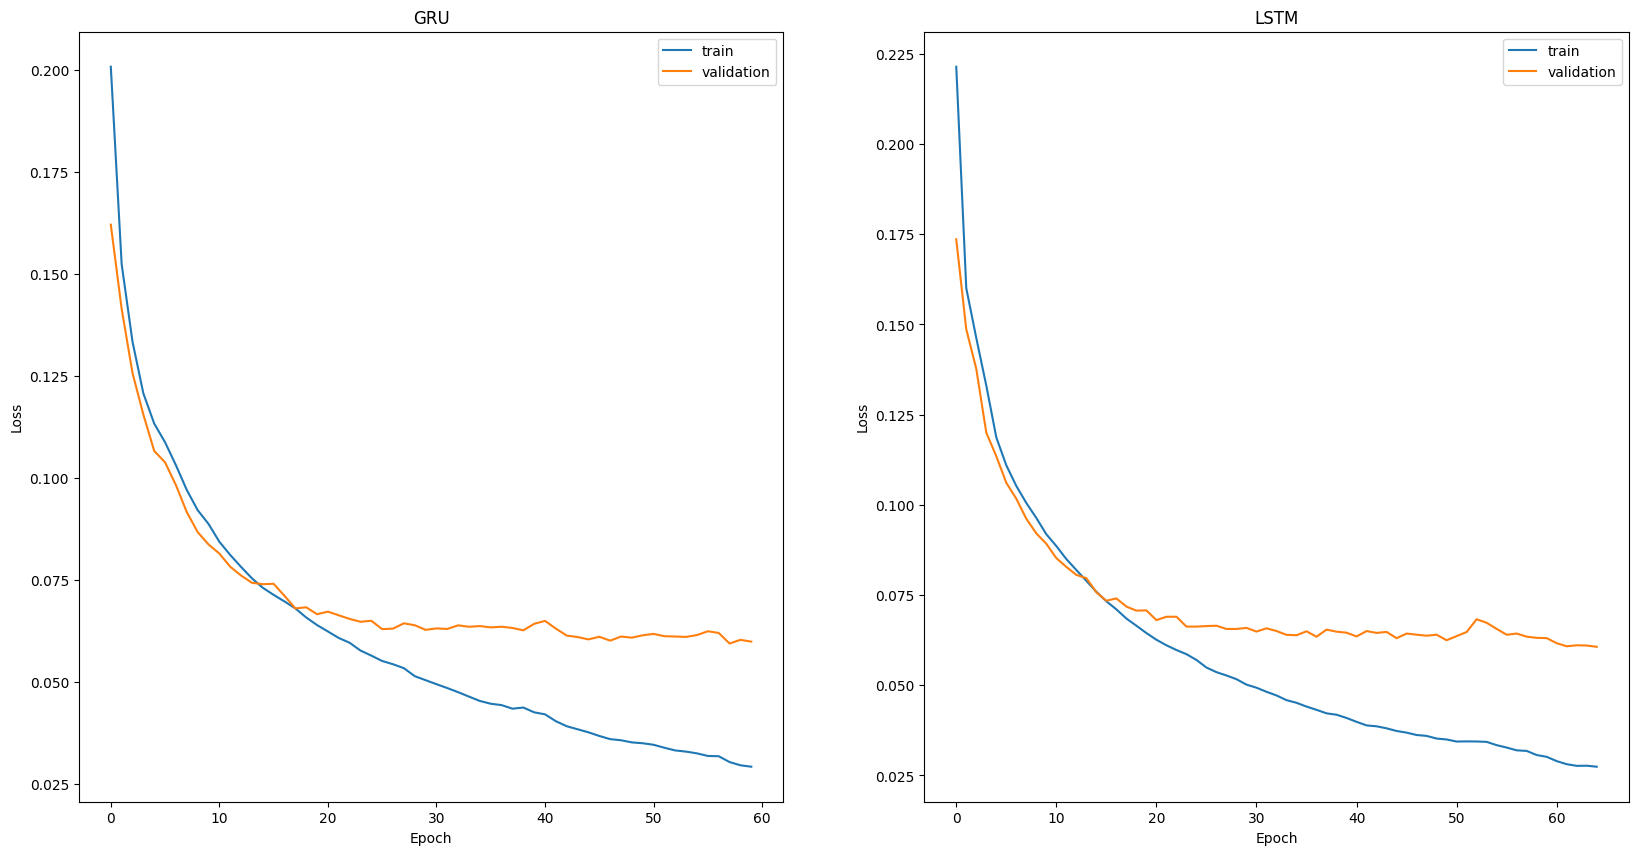

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].plot(history_gru.history["loss"])
ax[0].plot(history_gru.history["val_loss"])

ax[1].plot(history_lstm.history["loss"])
ax[1].plot(history_lstm.history["val_loss"])

ax[0].set_title("GRU")
ax[1].set_title("LSTM")

ax[0].legend(["train", "validation"], loc="upper right")
ax[1].legend(["train", "validation"], loc="upper right")

ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_xlabel("Epoch")



In [15]:
test_df = test.copy()
seq_len = int(test_df["seq_length"].iloc[0])
pred_len = int(test_df["seq_scored"].iloc[0])

test_inputs = preprocess_inputs(test_df, seq_len=seq_len)

gru_inf = build_model(gru=True, seq_len=seq_len, pred_len=pred_len)
lstm_inf = build_model(gru=False, seq_len=seq_len, pred_len=pred_len)

if os.path.exists("model_gru.weights.h5"):
    gru_inf.load_weights("model_gru.weights.h5")
else:
    gru_inf.set_weights(gru.get_weights())

if os.path.exists("model_lstm.weights.h5"):
    lstm_inf.load_weights("model_lstm.weights.h5")
else:
    lstm_inf.set_weights(lstm.get_weights())

gru_preds_scored = gru_inf.predict(test_inputs, batch_size=64, verbose=0)  # (N, 68, 5)
lstm_preds_scored = lstm_inf.predict(
    test_inputs, batch_size=64, verbose=0
)  # (N, 68, 5)

print(
    "gru_preds_scored:",
    gru_preds_scored.shape,
    "lstm_preds_scored:",
    lstm_preds_scored.shape,
)




gru_preds_scored: (240, 68, 5) lstm_preds_scored: (240, 68, 5)


In [16]:
def pad_to_full_length(pred_scored, seq_len, pred_len):
    n, pl, c = pred_scored.shape
    assert pl == pred_len
    if pred_len == seq_len:
        return pred_scored
    tail_len = seq_len - pred_len
    tail = np.repeat(pred_scored.mean(axis=1, keepdims=True), repeats=tail_len, axis=1)
    return np.concatenate([pred_scored, tail], axis=1)


gru_preds = pad_to_full_length(
    gru_preds_scored, seq_len=seq_len, pred_len=pred_len
)  # (N,107,5)
lstm_preds = pad_to_full_length(
    lstm_preds_scored, seq_len=seq_len, pred_len=pred_len
)  # (N,107,5)

print("padded gru_preds:", gru_preds.shape, "padded lstm_preds:", lstm_preds.shape)



padded gru_preds: (240, 107, 5) padded lstm_preds: (240, 107, 5)


In [17]:
preds_gru = []
for i, uid in enumerate(test_df.id.values):
    single_pred = gru_preds[i]
    single_df = pd.DataFrame(single_pred, columns=target_cols)
    single_df["id_seqpos"] = [f"{uid}_{x}" for x in range(single_df.shape[0])]
    preds_gru.append(single_df)

preds_gru_df = pd.concat(preds_gru, ignore_index=True)
preds_gru_df.head()



,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C,id_seqpos
0,0.721052,0.929917,0.612336,0.743924,0.366507,id_00b436dec_0
1,1.921628,3.588538,-0.384301,3.271627,0.515232,id_00b436dec_1
2,1.052302,0.922325,-0.943029,1.265509,0.705863,id_00b436dec_2
3,0.852780,0.359481,-1.211423,0.608067,0.508979,id_00b436dec_3
4,1.023168,2.158186,-1.012992,2.094807,0.713953,id_00b436dec_4


In [18]:
preds_lstm = []
for i, uid in enumerate(test_df.id.values):
    single_pred = lstm_preds[i]
    single_df = pd.DataFrame(single_pred, columns=target_cols)
    single_df["id_seqpos"] = [f"{uid}_{x}" for x in range(single_df.shape[0])]
    preds_lstm.append(single_df)

preds_lstm_df = pd.concat(preds_lstm, ignore_index=True)
preds_lstm_df.head()



,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C,id_seqpos
0,0.921069,0.881611,0.386789,0.781459,-0.098857,id_00b436dec_0
1,2.154127,3.743859,0.256934,3.656315,-0.074890,id_00b436dec_1
2,1.514302,0.975441,-0.337299,1.235751,-0.737154,id_00b436dec_2
3,1.093550,0.476313,0.214436,0.603152,-0.237946,id_00b436dec_3
4,1.396766,2.058563,0.514239,1.936079,0.012729,id_00b436dec_4


In [19]:
blend_preds_df = pd.DataFrame()
blend_preds_df["id_seqpos"] = preds_gru_df["id_seqpos"]
blend_preds_df["reactivity"] = (
    0.5 * preds_gru_df["reactivity"] + 0.5 * preds_lstm_df["reactivity"]
)
blend_preds_df["deg_Mg_pH10"] = (
    0.5 * preds_gru_df["deg_Mg_pH10"] + 0.5 * preds_lstm_df["deg_Mg_pH10"]
)
blend_preds_df["deg_pH10"] = (
    0.5 * preds_gru_df["deg_pH10"] + 0.5 * preds_lstm_df["deg_pH10"]
)
blend_preds_df["deg_Mg_50C"] = (
    0.5 * preds_gru_df["deg_Mg_50C"] + 0.5 * preds_lstm_df["deg_Mg_50C"]
)
blend_preds_df["deg_50C"] = (
    0.5 * preds_gru_df["deg_50C"] + 0.5 * preds_lstm_df["deg_50C"]
)
blend_preds_df.head()



,id_seqpos,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,id_00b436dec_0,0.821061,0.905764,0.499562,0.762691,0.133825
1,id_00b436dec_1,2.037878,3.666199,-0.063684,3.463971,0.220171
2,id_00b436dec_2,1.283302,0.948883,-0.640164,1.250630,-0.015645
3,id_00b436dec_3,0.973165,0.417897,-0.498494,0.605609,0.135516
4,id_00b436dec_4,1.209967,2.108375,-0.249376,2.015443,0.363341


In [20]:
submission = sample_sub[["id_seqpos"]].merge(blend_preds_df, on="id_seqpos", how="left")

for c in target_cols:
    submission[c] = submission[c].astype(np.float32).fillna(0.0)

submission = submission[["id_seqpos"] + target_cols]
submission = submission.reset_index(drop=True)

print(submission.shape)
print("Any NaNs:", submission.isna().any().to_dict())
assert (
    submission.shape[0] == sample_sub.shape[0]
), "Row count mismatch vs sample submission"
assert submission.columns.tolist() == ["id_seqpos"] + target_cols, "Column mismatch"
submission.head()



(25680, 6)
Any NaNs: {'id_seqpos': False, 'reactivity': False, 'deg_Mg_pH10': False, 'deg_pH10': False, 'deg_Mg_50C': False, 'deg_50C': False}


,id_seqpos,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,id_00b436dec_0,0.821061,0.905764,0.499562,0.762691,0.133825
1,id_00b436dec_1,2.037878,3.666199,-0.063684,3.463971,0.220171
2,id_00b436dec_2,1.283302,0.948883,-0.640164,1.250630,-0.015645
3,id_00b436dec_3,0.973165,0.417897,-0.498494,0.605609,0.135516
4,id_00b436dec_4,1.209967,2.108375,-0.249376,2.015443,0.363341


In [21]:
submission.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv")
print("Columns:", submission.columns.tolist())
print(
    "First/last id_seqpos:",
    submission["id_seqpos"].iloc[0],
    submission["id_seqpos"].iloc[-1],
)

Submission saved to submission.csv
Columns: ['id_seqpos', 'reactivity', 'deg_Mg_pH10', 'deg_pH10', 'deg_Mg_50C', 'deg_50C']
First/last id_seqpos: id_00b436dec_0 id_ff103a85c_106
